# EDA: test_set_no_answer.csv

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
pd.set_option('display.max_colwidth', 80)


In [2]:
df = pd.read_csv('../data/test_set_no_answer.csv')
df.shape

(94826, 2)

In [3]:
df.head()

,context,first letter
0,ukraine and poland agreed to help each other in their efforts to,j
1,"richard blumenthal , the longtime attorney general of connecticut , withstoo...",t
2,the leaders of france and britain say the countdown has begun for uncooperat...,t
3,""" some of the things i did in 1111 , i ' m better at",n
4,"the white house , acknowledging that it was still short of the votes needed ...",","


## Basic info

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 94826 entries, 0 to 94825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   context       94826 non-null  str  
 1   first letter  94826 non-null  str  
dtypes: str(2)
memory usage: 1.4 MB


In [5]:
df.isna().sum()

context         0
first letter    0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(5351)

## Context length distribution (words / chars)

In [7]:
df['ctx_word_len'] = df['context'].str.split().str.len()
df['ctx_char_len'] = df['context'].str.len()
df[['ctx_word_len','ctx_char_len']].describe()

,ctx_word_len,ctx_char_len
count,94826.000000,94826.000000
mean,24.885844,137.056240
std,6.864339,36.387114
min,8.000000,28.000000
25%,21.000000,114.000000
50%,24.000000,137.000000
75%,29.000000,159.000000
max,88.000000,389.000000


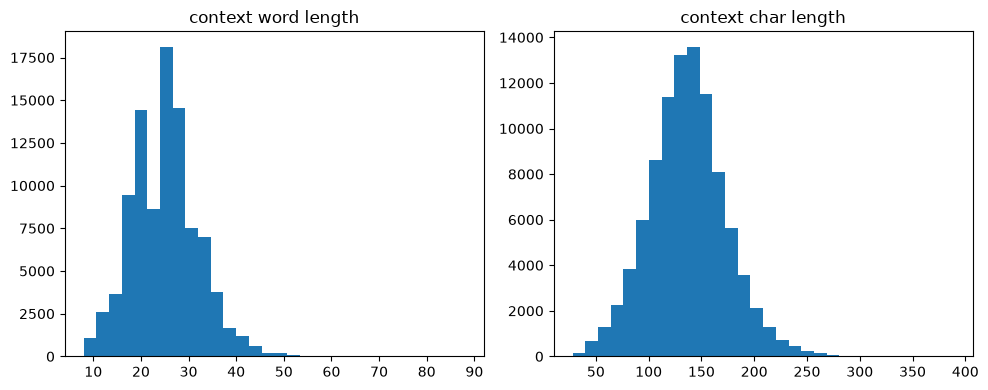

In [8]:
fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].hist(df['ctx_word_len'], bins=30); ax[0].set_title('context word length')
ax[1].hist(df['ctx_char_len'], bins=30); ax[1].set_title('context char length')
plt.tight_layout(); plt.show()

## First letter distribution

In [9]:
df['first letter'].value_counts()

first letter
t    12845
a     9809
s     6749
o     5708
i     5258
,     4868
c     4736
f     4090
p     3869
w     3692
b     3524
m     2985
r     2840
h     2716
d     2619
-     2296
l     2134
e     2088
1     1938
n     1788
g     1384
'     1277
u     1144
.      817
k      570
y      549
v      541
j      490
"      447
[      353
q      193
$       91
_       90
z       86
]       60
U       47
x       45
:       41
&       14
/       14
\       11
!        3
?        3
;        2
+        1
*        1
Name: count, dtype: int64

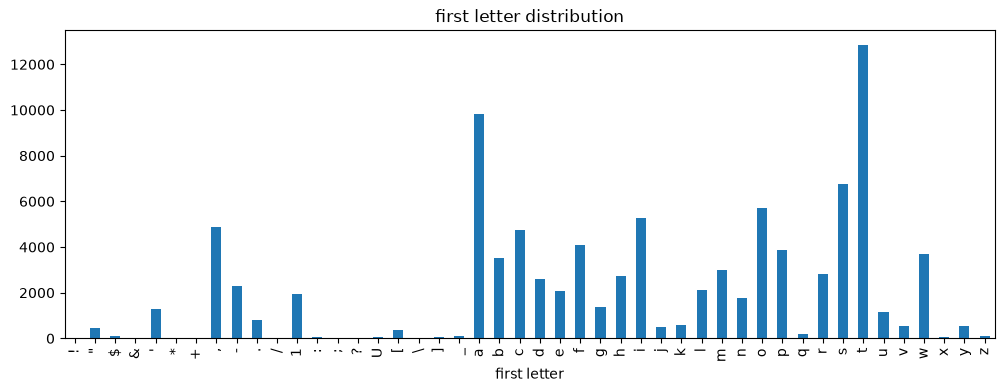

In [10]:
df['first letter'].value_counts().sort_index().plot.bar(figsize=(12,4), title='first letter distribution'); plt.show()

In [11]:

def categorize(tok):
    if re.fullmatch(r"[0-9]+", tok):
        return "number"
    if re.fullmatch(r"[a-z']+", tok, re.IGNORECASE):
        return "word"
    return "symbol"


## First-letter category: word / number / symbol
(no answer column in test set, so category is inferred from the first-letter field itself)

In [12]:
df['first_letter_cat'] = df['first letter'].astype(str).apply(categorize)
df['first_letter_cat'].value_counts()

first_letter_cat
word      83776
symbol     9112
number     1938
Name: count, dtype: int64

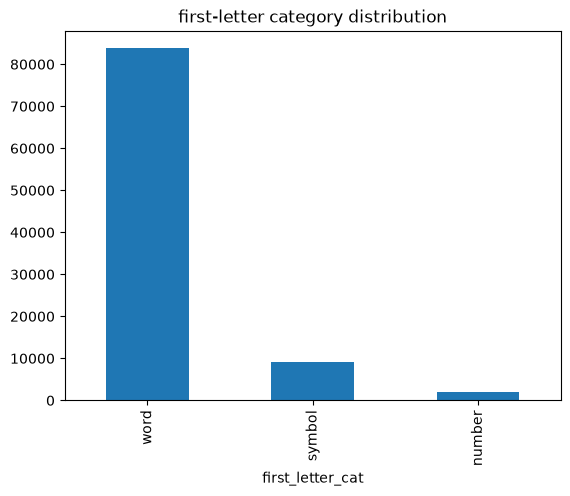

In [13]:
df['first_letter_cat'].value_counts().plot.bar(title='first-letter category distribution'); plt.show()

## Token list for test (candidate words in context vocab starting with each letter)
No ground-truth answer exists for test, so we list the unique context vocabulary instead.

In [14]:
ctx_tokens = pd.Series(' '.join(df['context']).split())
ctx_vocab = ctx_tokens.value_counts()
print('unique context tokens:', ctx_vocab.shape[0])
ctx_vocab.head(30)

unique context tokens: 44450


the      115950
,         73622
a         65317
-         64957
of        62306
to        57006
in        50427
and       35866
s         33570
'         32526
on        29971
.         29656
for       20654
11        20146
1         17734
that      16205
with      12969
at        11414
an        11356
as        11233
has       10342
111       10174
"          9958
by         9825
from       9714
said       9245
was        8922
will       8490
lrb        8485
[UNK]      8477
Name: count, dtype: int64

In [15]:
token_list_test = sorted(ctx_vocab.index.tolist())
len(token_list_test)

44450

In [16]:
import json
with open('../data/test_token_list.json','w') as f:
    json.dump(token_list_test, f)
print('saved test_token_list.json')

saved test_token_list.json


## Cross-check against dev token list

In [17]:
import json
try:
    with open('../data/dev_token_list.json') as f:
        dev_tokens = set(json.load(f))
    overlap = dev_tokens & set(token_list_test)
    print('test vocab size:', len(token_list_test))
    print('dev answer vocab size:', len(dev_tokens))
    print('overlap:', len(overlap))
except FileNotFoundError:
    print('run dev_eda.ipynb first to generate dev_token_list.json')

test vocab size: 44450
dev answer vocab size: 10310
overlap: 9730
